# Analysis of the Reconstructed Matrices

In [85]:
from pathlib import Path
import json
import sys
import warnings
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform
from scipy.sparse.csgraph import minimum_spanning_tree

np.set_printoptions(suppress=True, precision=4)
warnings.filterwarnings('ignore', message='.*Clustering large matrix.*')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


# Step 1: Load Full Reconstructed Dataset (Local PC)
Load reconstructed matrices.

In [86]:
WINDOW_LENGTH = 724
STRIDE = 10
DATASET_NAME = f'data_00_20_w{WINDOW_LENGTH}_s{STRIDE}'
RUN_NAME = 'linearAE_005'
FILE_NAME = f'all_reconstructed_{RUN_NAME}.pt'

project_root = Path.cwd().resolve().parent
base_dir = project_root / 'data' / 'processed' / 'dataset'
dataset_dir = base_dir / DATASET_NAME

ALL_RECONSTRUCTED_MATRIX_FILE = dataset_dir / FILE_NAME
RESULTS_FOLDER = project_root / 'results' / DATASET_NAME / 'reconstruction_analysis' / RUN_NAME
RESULTS_FOLDER.mkdir(parents=True, exist_ok=True)

if not ALL_RECONSTRUCTED_MATRIX_FILE.exists():
    raise FileNotFoundError(
        f"File '{ALL_RECONSTRUCTED_MATRIX_FILE.name}' not found in: {dataset_dir.absolute()}"
    )

print(f'Dataset selected: {DATASET_NAME}')
print(f'All Reconstructed Matrix: {ALL_RECONSTRUCTED_MATRIX_FILE.name}')

Dataset selected: data_00_20_w724_s10
All Reconstructed Matrix: all_reconstructed_linearAE_005.pt


In [87]:
def load_corr_payload(pt_path: Path):
    payload = torch.load(pt_path, map_location='cpu')
    corr_tensor = payload.get('corr_tensor', None)
    recon_tensor = payload.get('corr_tensor_reconstructed', None)
    indices = payload.get('indices', None)
    meta = {k: v for k, v in payload.items() if k != 'corr_tensor'}

    if corr_tensor is None:
        raise KeyError('corr_tensor key not found in .pt file')
    if recon_tensor is None:
        raise KeyError('corr_tensor_reconstructed key not found in .pt file')
    if corr_tensor.ndim != 3 or corr_tensor.shape[1] != corr_tensor.shape[2]:
        raise ValueError(f'Invalid shape for corr_tensor: {corr_tensor.shape}')
    if recon_tensor.ndim != 3 or recon_tensor.shape[1] != recon_tensor.shape[2]:
        raise ValueError(f'Invalid shape for corr_tensor_reconstructed: {recon_tensor.shape}')

    return corr_tensor.float(), recon_tensor.float(), indices, meta


gt_corr, recon_corr, indices, meta = load_corr_payload(ALL_RECONSTRUCTED_MATRIX_FILE)

print(f'Ground truth correlation tensor shape: {gt_corr.shape}')
print(f'Reconstructed correlation tensor shape: {recon_corr.shape}')
print(f'Indices: {indices[:10]}')
print(f'Metadata keys: {list(meta.keys())}')
print(gt_corr[:1,:5,:5])
print(recon_corr[:1,:5,:5])

num_windows, num_assets, _ = gt_corr.shape
print(f'\nNumber of windows: {num_windows}, Number of assets: {num_assets}')


Ground truth correlation tensor shape: torch.Size([412, 362, 362])
Reconstructed correlation tensor shape: torch.Size([412, 362, 362])
Indices: [49, 50, 51, 52, 53, 54, 55, 56, 57, 58]
Metadata keys: ['indices', 'split', 'meta', 'corr_tensor_reconstructed', 'tickers']
tensor([[[1.0000, 0.1305, 0.1530, 0.2544, 0.4250],
         [0.1305, 1.0000, 0.1224, 0.3038, 0.1635],
         [0.1530, 0.1224, 1.0000, 0.1499, 0.2088],
         [0.2544, 0.3038, 0.1499, 1.0000, 0.2217],
         [0.4250, 0.1635, 0.2088, 0.2217, 1.0000]]])
tensor([[[0.8124, 0.2094, 0.2340, 0.2101, 0.3013],
         [0.2125, 0.7667, 0.1785, 0.2375, 0.1749],
         [0.1788, 0.1856, 0.8463, 0.2609, 0.2713],
         [0.2061, 0.2639, 0.1971, 0.8735, 0.3032],
         [0.3189, 0.2817, 0.2321, 0.2207, 0.8040]]])

Number of windows: 412, Number of assets: 362


In [88]:
SAMPLE_GLOBAL_IDX = 49
SAMPLE_FOLDER = RESULTS_FOLDER / f'sample_{SAMPLE_GLOBAL_IDX}'

if SAMPLE_GLOBAL_IDX not in indices:
    raise ValueError(f'SAMPLE_GLOBAL_IDX {SAMPLE_GLOBAL_IDX} not found in indices list')

SAMPLE_IDX = int(np.where(np.array(indices) == SAMPLE_GLOBAL_IDX)[0][0])

orig_mat = gt_corr[SAMPLE_IDX].detach().cpu().numpy()
recon_mat = recon_corr[SAMPLE_IDX].detach().cpu().numpy()
err_mat = recon_mat - orig_mat

print(f'Global sample index: {SAMPLE_GLOBAL_IDX}')
print(f'Local tensor position: {SAMPLE_IDX}\n')
print(f"Original Matrix:\n{orig_mat[:5, :5]}")  # Print the top-left 5x5 block of the original matrix for inspection
print(f"Reconstructed Matrix:\n{recon_mat[:5, :5]}")  # Print the top-left 5x5 block of the reconstructed matrix for inspection
print(f"Error Matrix:\n{err_mat[:5, :5]}")  # Print the top-left 5x5 block of the error matrix for inspection

mse_sample = float(np.mean((err_mat) ** 2))
mae_sample = float(np.mean(np.abs(err_mat)))
fro_sample = float(np.linalg.norm(err_mat, ord='fro'))


print(f'\nMSE: {mse_sample:.6f} | MAE: {mae_sample:.6f} | Frobenius: {fro_sample:.6f}')
print(f'Original Matrix range - Min: {orig_mat.min():.6f} | Max: {orig_mat.max():.6f}')
print(f'Reconstructed Matrix range - Min: {recon_mat.min():.6f} | Max: {recon_mat.max():.6f}')
print(f'Error range - Min: {err_mat.min():.6f} | Max: {err_mat.max():.6f}')


Global sample index: 49
Local tensor position: 0

Original Matrix:
[[1.     0.1305 0.153  0.2544 0.425 ]
 [0.1305 1.     0.1224 0.3038 0.1635]
 [0.153  0.1224 1.     0.1499 0.2088]
 [0.2544 0.3038 0.1499 1.     0.2217]
 [0.425  0.1635 0.2088 0.2217 1.    ]]
Reconstructed Matrix:
[[0.8124 0.2094 0.234  0.2101 0.3013]
 [0.2125 0.7667 0.1785 0.2375 0.1749]
 [0.1788 0.1856 0.8463 0.2609 0.2713]
 [0.2061 0.2639 0.1971 0.8735 0.3032]
 [0.3189 0.2817 0.2321 0.2207 0.804 ]]
Error Matrix:
[[-0.1876  0.0789  0.081  -0.0443 -0.1236]
 [ 0.082  -0.2333  0.0562 -0.0663  0.0114]
 [ 0.0257  0.0633 -0.1537  0.111   0.0625]
 [-0.0484 -0.0399  0.0471 -0.1265  0.0815]
 [-0.106   0.1182  0.0233 -0.001  -0.196 ]]

MSE: 0.009624 | MAE: 0.078219 | Frobenius: 35.512516
Original Matrix range - Min: -0.160982 | Max: 1.000000
Reconstructed Matrix range - Min: -0.046454 | Max: 0.942641
Error range - Min: -0.429989 | Max: 0.451534


# Property 0: Heatmap Analysis

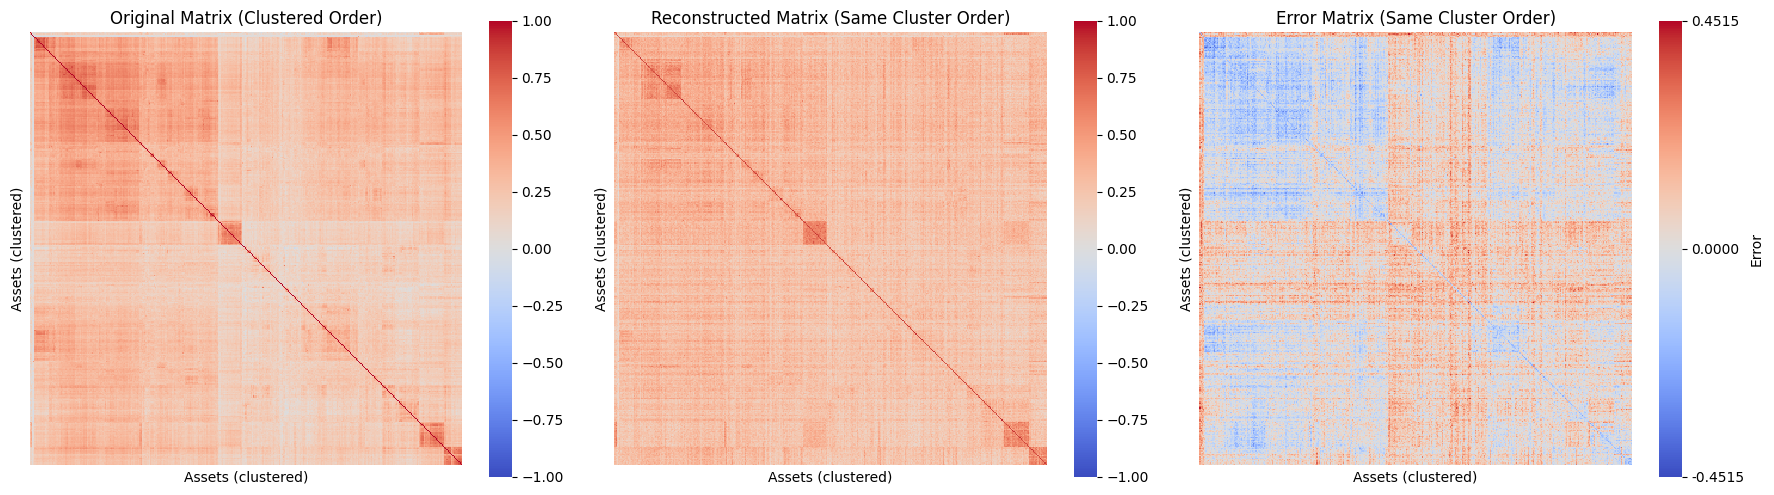

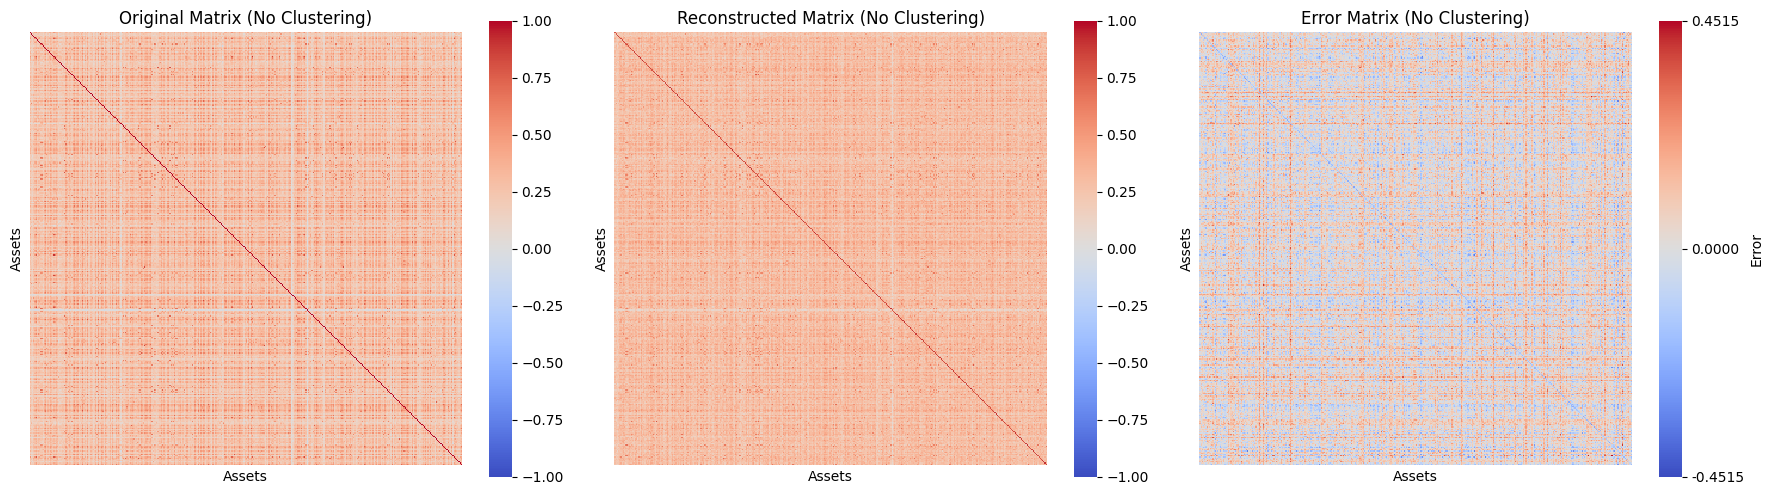

Saved heatmaps for global matrix index 49 (local position 0):
 - C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\results\data_00_20_w724_s10\reconstruction_analysis\linearAE_005\sample_49\property0\clustered_heatmaps.png
 - C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\results\data_00_20_w724_s10\reconstruction_analysis\linearAE_005\sample_49\property0\no_clustered_heatmaps.png


In [89]:
PROPERTY_0_FOLDER = SAMPLE_FOLDER / 'property0'
PROPERTY_0_FOLDER.mkdir(parents=True, exist_ok=True)

shared_cmap = 'coolwarm'
err_abs_max = float(np.max(np.abs(err_mat)))
if err_abs_max == 0:
    err_abs_max = 1e-6

# Build a single cluster ordering from the original matrix and reuse it for all three panels.
cluster_ref = sns.clustermap(
    orig_mat,
    vmin=-1,
    vmax=1,
    cmap=shared_cmap,
    linewidths=0,
    figsize=(8, 8),
    cbar_kws={'label': 'Correlation'},
)
row_order = cluster_ref.dendrogram_row.reordered_ind
col_order = cluster_ref.dendrogram_col.reordered_ind
plt.close(cluster_ref.figure)

orig_mat_clustered = orig_mat[np.ix_(row_order, col_order)]
recon_mat_clustered = recon_mat[np.ix_(row_order, col_order)]
err_mat_clustered = err_mat[np.ix_(row_order, col_order)]

fig_cluster, axes_cluster = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(
    orig_mat_clustered,
    ax=axes_cluster[0],
    vmin=-1,
    vmax=1,
    cmap=shared_cmap,
    square=True,
)
axes_cluster[0].set_title('Original Matrix (Clustered Order)')

sns.heatmap(
    recon_mat_clustered,
    ax=axes_cluster[1],
    vmin=-1,
    vmax=1,
    cmap=shared_cmap,
    square=True,
)
axes_cluster[1].set_title('Reconstructed Matrix (Same Cluster Order)')

hm_cluster_err = sns.heatmap(
    err_mat_clustered,
    ax=axes_cluster[2],
    vmin=-err_abs_max,
    vmax=err_abs_max,
    cmap=shared_cmap,
    center=0,
    square=True,
    cbar_kws={'label': 'Error'},
)
axes_cluster[2].set_title('Error Matrix (Same Cluster Order)')

cbar_cluster = hm_cluster_err.collections[0].colorbar
cbar_cluster.set_ticks([-err_abs_max, 0, err_abs_max])
cbar_cluster.set_ticklabels([f'{-err_abs_max:.4f}', '0.0000', f'{err_abs_max:.4f}'])

for ax in axes_cluster:
    ax.set_xlabel('Assets (clustered)')
    ax.set_ylabel('Assets (clustered)')
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
path_cluster = PROPERTY_0_FOLDER / 'clustered_heatmaps.png'
fig_cluster.savefig(path_cluster, dpi=150, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(orig_mat, ax=axes[0], vmin=-1, vmax=1, cmap=shared_cmap, square=True)
axes[0].set_title('Original Matrix (No Clustering)')

sns.heatmap(recon_mat, ax=axes[1], vmin=-1, vmax=1, cmap=shared_cmap, square=True)
axes[1].set_title('Reconstructed Matrix (No Clustering)')

hm = sns.heatmap(
    err_mat,
    ax=axes[2],
    vmin=-err_abs_max,
    vmax=err_abs_max,
    cmap=shared_cmap,
    center=0,
    square=True,
    cbar_kws={'label': 'Error'},
)
axes[2].set_title('Error Matrix (No Clustering)')

cbar_std = hm.collections[0].colorbar
cbar_std.set_ticks([-err_abs_max, 0, err_abs_max])
cbar_std.set_ticklabels([f'{-err_abs_max:.4f}', '0.0000', f'{err_abs_max:.4f}'])

for ax in axes:
    ax.set_xlabel('Assets')
    ax.set_ylabel('Assets')
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
path_no_cluster = PROPERTY_0_FOLDER / 'no_clustered_heatmaps.png'
fig.savefig(path_no_cluster, dpi=150, bbox_inches='tight')
plt.show()

print(f'Saved heatmaps for global matrix index {SAMPLE_GLOBAL_IDX} (local position {SAMPLE_IDX}):')
print(f' - {path_cluster}')
print(f' - {path_no_cluster}')


# Property 1: The distribution of pairwise correlations is significantly shifted towards positive values


✓ Comparison plot saved to: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\results\data_00_20_w724_s10\reconstruction_analysis\linearAE_005\sample_49\property1\correlation_comparison_distribution.png

--- Statistics for Ground Truth ---
Mean: 0.2753 | Std: 0.1204 | Min: -0.1610 | Max: 0.9072
Positive: 65033 (99.53%) | Negative: 308 (0.47%) | Zero: 0 (0.00%)

--- Statistics for Reconstruction ---
Mean: 0.2985 | Std: 0.0859 | Min: -0.0465 | Max: 0.7814
Positive: 65339 (100.00%) | Negative: 2 (0.00%) | Zero: 0 (0.00%)


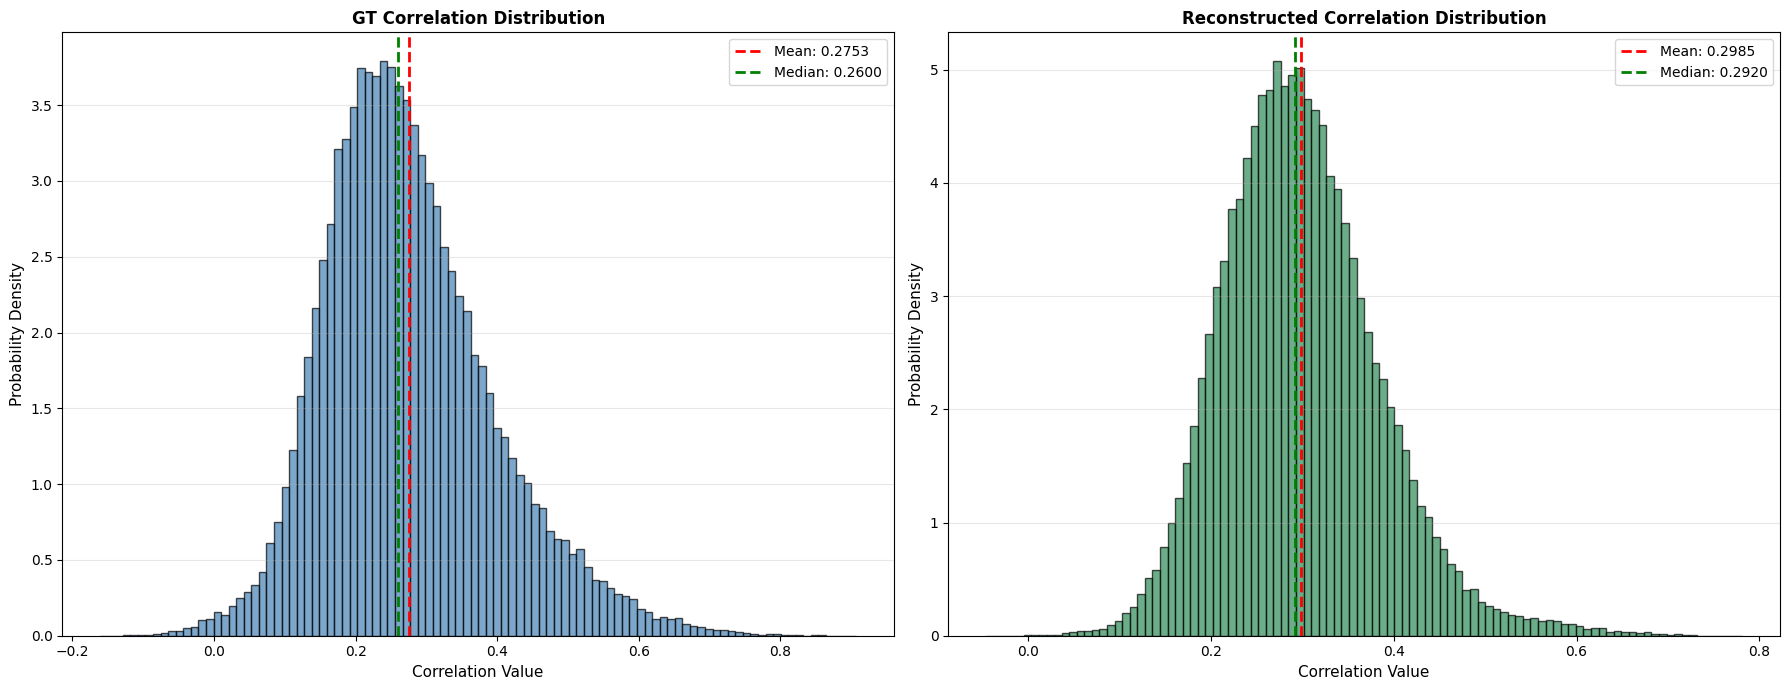

In [90]:
PROPERTY_1_FOLDER = SAMPLE_FOLDER / 'property1'
PROPERTY_1_FOLDER.mkdir(parents=True, exist_ok=True)


triu_indices = torch.triu_indices(num_assets, num_assets, offset=1)

# Estrazione valori per Ground Truth e Reconstruction
gt_values = gt_corr[SAMPLE_IDX][triu_indices[0], triu_indices[1]]
recon_values = recon_corr[SAMPLE_IDX][triu_indices[0], triu_indices[1]]

# --- Visualizzazione ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Grafico 1: Ground Truth Correlation
ax1.hist(gt_values.numpy(), bins=100, color='steelblue', edgecolor='black', alpha=0.7, density=True)
ax1.axvline(torch.mean(gt_values).item(), color='red', linestyle='--', linewidth=2, label=f'Mean: {torch.mean(gt_values):.4f}')
ax1.axvline(torch.median(gt_values).item(), color='green', linestyle='--', linewidth=2, label=f'Median: {torch.median(gt_values):.4f}')
ax1.set_xlabel('Correlation Value', fontsize=11)
ax1.set_ylabel('Probability Density', fontsize=11)
ax1.set_title(f'GT Correlation Distribution', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Grafico 2: Reconstructed Correlation
ax2.hist(recon_values.numpy(), bins=100, color='seagreen', edgecolor='black', alpha=0.7, density=True)
ax2.axvline(torch.mean(recon_values).item(), color='red', linestyle='--', linewidth=2, label=f'Mean: {torch.mean(recon_values):.4f}')
ax2.axvline(torch.median(recon_values).item(), color='green', linestyle='--', linewidth=2, label=f'Median: {torch.median(recon_values):.4f}')
ax2.set_xlabel('Correlation Value', fontsize=11)
ax2.set_ylabel('Probability Density', fontsize=11)
ax2.set_title(f'Reconstructed Correlation Distribution', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()

# Salvataggio
plot_path = PROPERTY_1_FOLDER / 'correlation_comparison_distribution.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
print(f"\n✓ Comparison plot saved to: {plot_path}")

# --- Statistiche veloci in console ---
def print_stats(name, values):
    print(f"\n--- Statistics for {name} ---")
    print(f"Mean: {torch.mean(values):.4f} | Std: {torch.std(values):.4f} | Min: {torch.min(values):.4f} | Max: {torch.max(values):.4f}")
    pos = torch.sum(values > 0).item()
    neg = torch.sum(values < 0).item()
    zero = torch.sum(values == 0).item()
    print(f"Positive: {pos} ({100*pos/len(values):.2f}%) | Negative: {neg} ({100*neg/len(values):.2f}%) | Zero: {zero} ({100*zero/len(values):.2f}%)")

print_stats("Ground Truth", gt_values)
print_stats("Reconstruction", recon_values)

plt.show()

# Property 2: Eigenvalues follow the Marchenko–Pastur distribution, except for a very large first eigenvalue and a couple of other large eigenvalues

In [91]:
PROPERTY_2_FOLDER = SAMPLE_FOLDER / 'property2'
PROPERTY_2_FOLDER.mkdir(parents=True, exist_ok=True)

print(f"Computing eigendecomposition for global sample index {SAMPLE_GLOBAL_IDX}...")

evals_gt, evecs_gt = torch.linalg.eigh(gt_corr[SAMPLE_IDX])
evals_recon, evecs_recon = torch.linalg.eigh(recon_corr[SAMPLE_IDX])

# Reverse to get descending order (highest eigenvalues first)
evals_gt = torch.flip(evals_gt, dims=[0])
evecs_gt = torch.flip(evecs_gt, dims=[1])
evals_recon = torch.flip(evals_recon, dims=[0])
evecs_recon = torch.flip(evecs_recon, dims=[1])

print(f"✓ Eigendecomposition complete!")

evals_gt_np = evals_gt.cpu().numpy()
evals_recon_np = evals_recon.cpu().numpy()
evecs_gt_np = evecs_gt.cpu().numpy()
evecs_recon_np = evecs_recon.cpu().numpy()
negative_eigenvalues_count_gt = np.sum(evals_gt_np < 0)
negative_eigenvalues_count_recon = np.sum(evals_recon_np < 0)
print(f"\nNumber of negative eigenvalues (Ground Truth): {negative_eigenvalues_count_gt}")
print(f"Number of negative eigenvalues (Reconstruction): {negative_eigenvalues_count_recon}")


Computing eigendecomposition for global sample index 49...
✓ Eigendecomposition complete!

Number of negative eigenvalues (Ground Truth): 0
Number of negative eigenvalues (Reconstruction): 119


In [92]:
# ===== MARCHENKO-PASTUR FUNCTION =====
def marchenko_pastur_pdf(x, lmbd, sigma=1):
    """
    Marchenko-Pastur probability density function.

    Parameters:
    -----------
    x : float or array
        Eigenvalue
    lmbd : float
        Ratio of num_eigenvalues / num_time_points (N/T)
    sigma : float
        Standard deviation (typically 1 for correlation matrices)

    Returns:
    --------
    float or array
        Probability density at x
    """
    b = np.power(sigma * (1 + np.sqrt(lmbd)), 2)  # Largest eigenvalue
    a = np.power(sigma * (1 - np.sqrt(lmbd)), 2)  # Smallest eigenvalue

    # Vectorized calculation
    result = np.zeros_like(x, dtype=float)
    mask = (x >= a) & (x <= b)
    result[mask] = (1 / (2 * np.pi * sigma * sigma * x[mask] * lmbd)) * np.sqrt((b - x[mask]) * (x[mask] - a))

    return result

✓ Comparison plot saved to: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\results\data_00_20_w724_s10\reconstruction_analysis\linearAE_005\sample_49\property2\eigenvalue_comparison_marchenko_pastur.png

--- Eigenvalue Statistics ---
Eigenvalues above MP limit (GT): 11 | Max GT Eigenvalue: 107.254982
Eigenvalues above MP limit (Recon): 7 | Max Recon Eigenvalue: 110.819321
Eigenvalues below MP limit (GT): 44 | Min GT Eigenvalue: 0.028738
Eigenvalues below MP limit (Recon): 132 | Min Recon Eigenvalue: -1.227280

Negative eigenvalues (GT): 0
Negative eigenvalues (Recon): 119


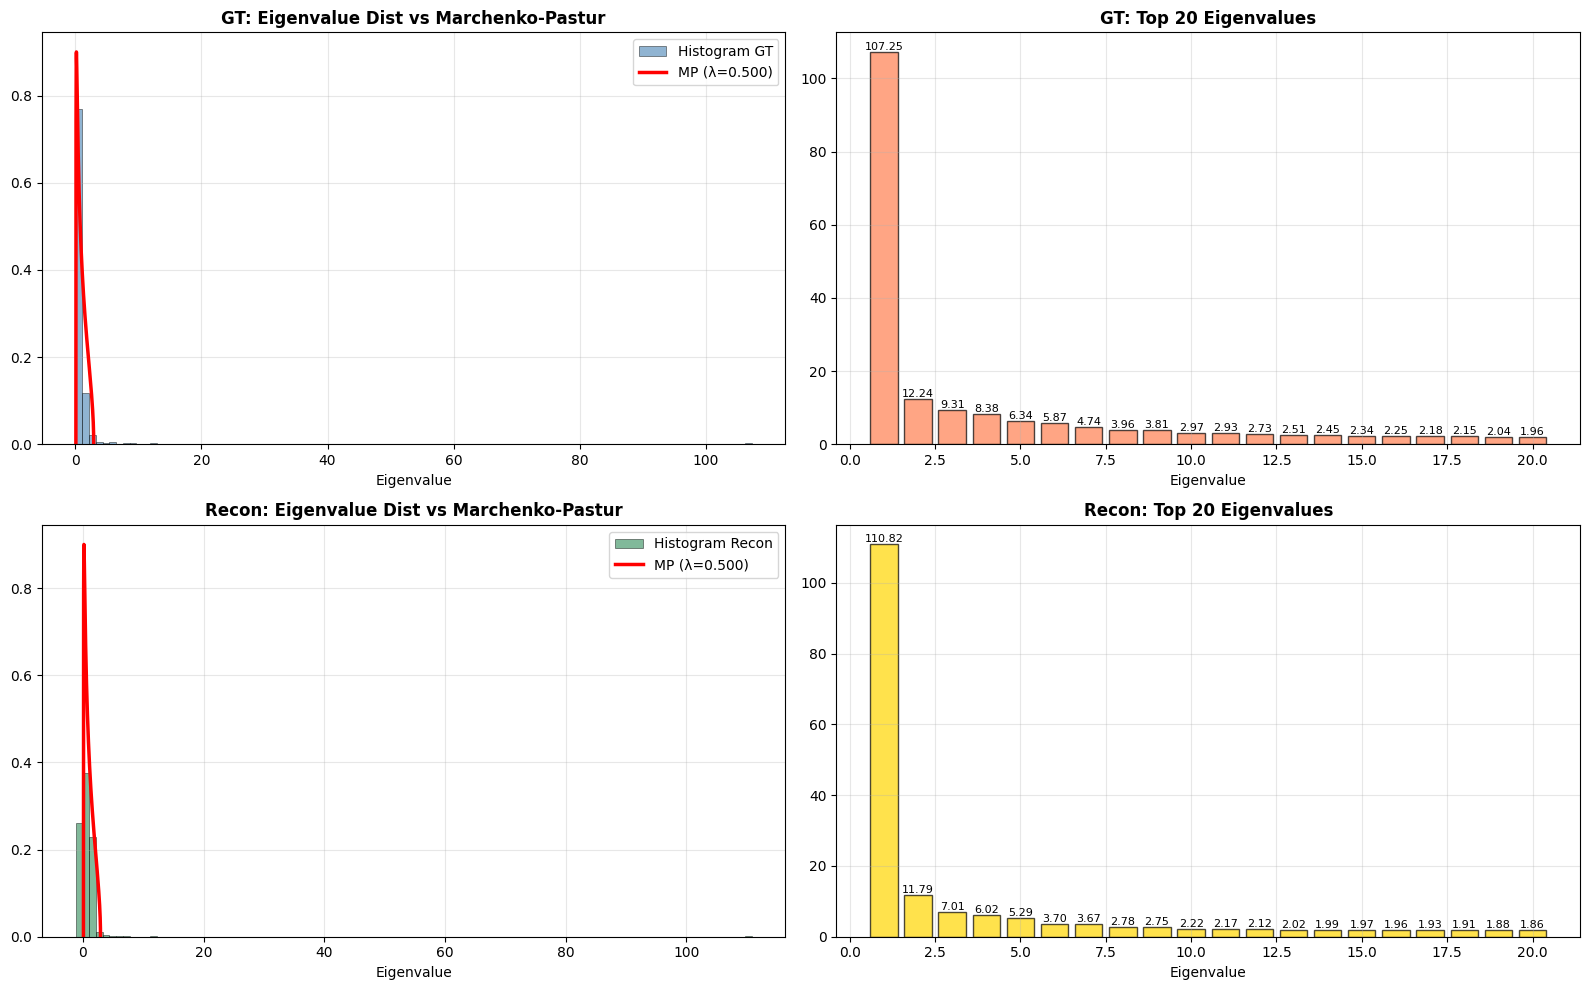

In [93]:
# Calcolo parametri MP (comuni a entrambi)
lmbd = num_assets / WINDOW_LENGTH
sigma = 1.0
b = np.power(sigma * (1 + np.sqrt(lmbd)), 2)
a = np.power(sigma * (1 - np.sqrt(lmbd)), 2)
x_theory = np.linspace(a, b, 500)
y_theory = marchenko_pastur_pdf(x_theory, lmbd, sigma)

# Creazione figura 2x2
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# --- RIGA 1: GROUND TRUTH (evals_gt_np) ---
data_gt = evals_gt_np
top_k = min(20, len(data_gt))

# Plot 1,1: Istogramma GT
axes[0, 0].hist(data_gt, bins=100, density=True, alpha=0.6, color='steelblue', edgecolor='black', linewidth=0.5, label='Histogram GT')
axes[0, 0].plot(x_theory, y_theory, 'r-', linewidth=2.5, label=f'MP (λ={lmbd:.3f})')
axes[0, 0].set_title('GT: Eigenvalue Dist vs Marchenko-Pastur', fontweight='bold')
axes[0, 0].legend()

# Plot 1,2: Top Eigenvalues GT
top_gt = np.sort(data_gt)[::-1][:top_k]
axes[0, 1].bar(np.arange(1, top_k + 1), top_gt, color='coral', edgecolor='black', alpha=0.7)
axes[0, 1].set_title(f'GT: Top {top_k} Eigenvalues', fontweight='bold')
for i, val in enumerate(top_gt):
    axes[0, 1].text(i+1, val, f'{val:.2f}', ha='center', va='bottom', fontsize=8)

# --- RIGA 2: RECONSTRUCTED (evals_recon_np) ---
data_recon = evals_recon_np

# Plot 2,1: Istogramma Recon
axes[1, 0].hist(data_recon, bins=100, density=True, alpha=0.6, color='seagreen', edgecolor='black', linewidth=0.5, label='Histogram Recon')
axes[1, 0].plot(x_theory, y_theory, 'r-', linewidth=2.5, label=f'MP (λ={lmbd:.3f})')
axes[1, 0].set_title('Recon: Eigenvalue Dist vs Marchenko-Pastur', fontweight='bold')
axes[1, 0].legend()

# Plot 2,2: Top Eigenvalues Recon
top_recon = np.sort(data_recon)[::-1][:top_k]
axes[1, 1].bar(np.arange(1, top_k + 1), top_recon, color='gold', edgecolor='black', alpha=0.7)
axes[1, 1].set_title(f'Recon: Top {top_k} Eigenvalues', fontweight='bold')
for i, val in enumerate(top_recon):
    axes[1, 1].text(i+1, val, f'{val:.2f}', ha='center', va='bottom', fontsize=8)

# Formattazione comune
for ax in axes.flat:
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('Eigenvalue')

plt.tight_layout()

# Salvataggio e Print statistiche (facoltativo per i Recon)
plot_path = PROPERTY_2_FOLDER / 'eigenvalue_comparison_marchenko_pastur.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
print(f"✓ Comparison plot saved to: {plot_path}")

print(f"\n--- Eigenvalue Statistics ---")
print(f"Eigenvalues above MP limit (GT): {np.sum(data_gt > b)} | Max GT Eigenvalue: {np.max(data_gt):.6f}")
print(f"Eigenvalues above MP limit (Recon): {np.sum(data_recon > b)} | Max Recon Eigenvalue: {np.max(data_recon):.6f}")
print(f"Eigenvalues below MP limit (GT): {np.sum(data_gt < a)} | Min GT Eigenvalue: {np.min(data_gt):.6f}")
print(f"Eigenvalues below MP limit (Recon): {np.sum(data_recon < a)} | Min Recon Eigenvalue: {np.min(data_recon):.6f}")
print()
print(f"Negative eigenvalues (GT): {np.sum(data_gt < 0)}")
print(f"Negative eigenvalues (Recon): {np.sum(data_recon < 0)}")

plt.show()

# Property 3: The Perron-Frobenius property holds true (first eigenvector has positive entries and has multiplicity one)


OVERLAY COMPARISON: TOP 3 EIGENVECTORS (global sample index 49, local position 0)
Eigenvector #1 (Market Mode):
  GT    -> PF Satisfied: True, Min: 0.000720, Max: 0.079101
  Recon -> PF Satisfied: True, Min: 0.021353, Max: 0.069059

✓ Overlay comparison plot saved to: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\results\data_00_20_w724_s10\reconstruction_analysis\linearAE_005\sample_49\property3\perron_frobenius.png


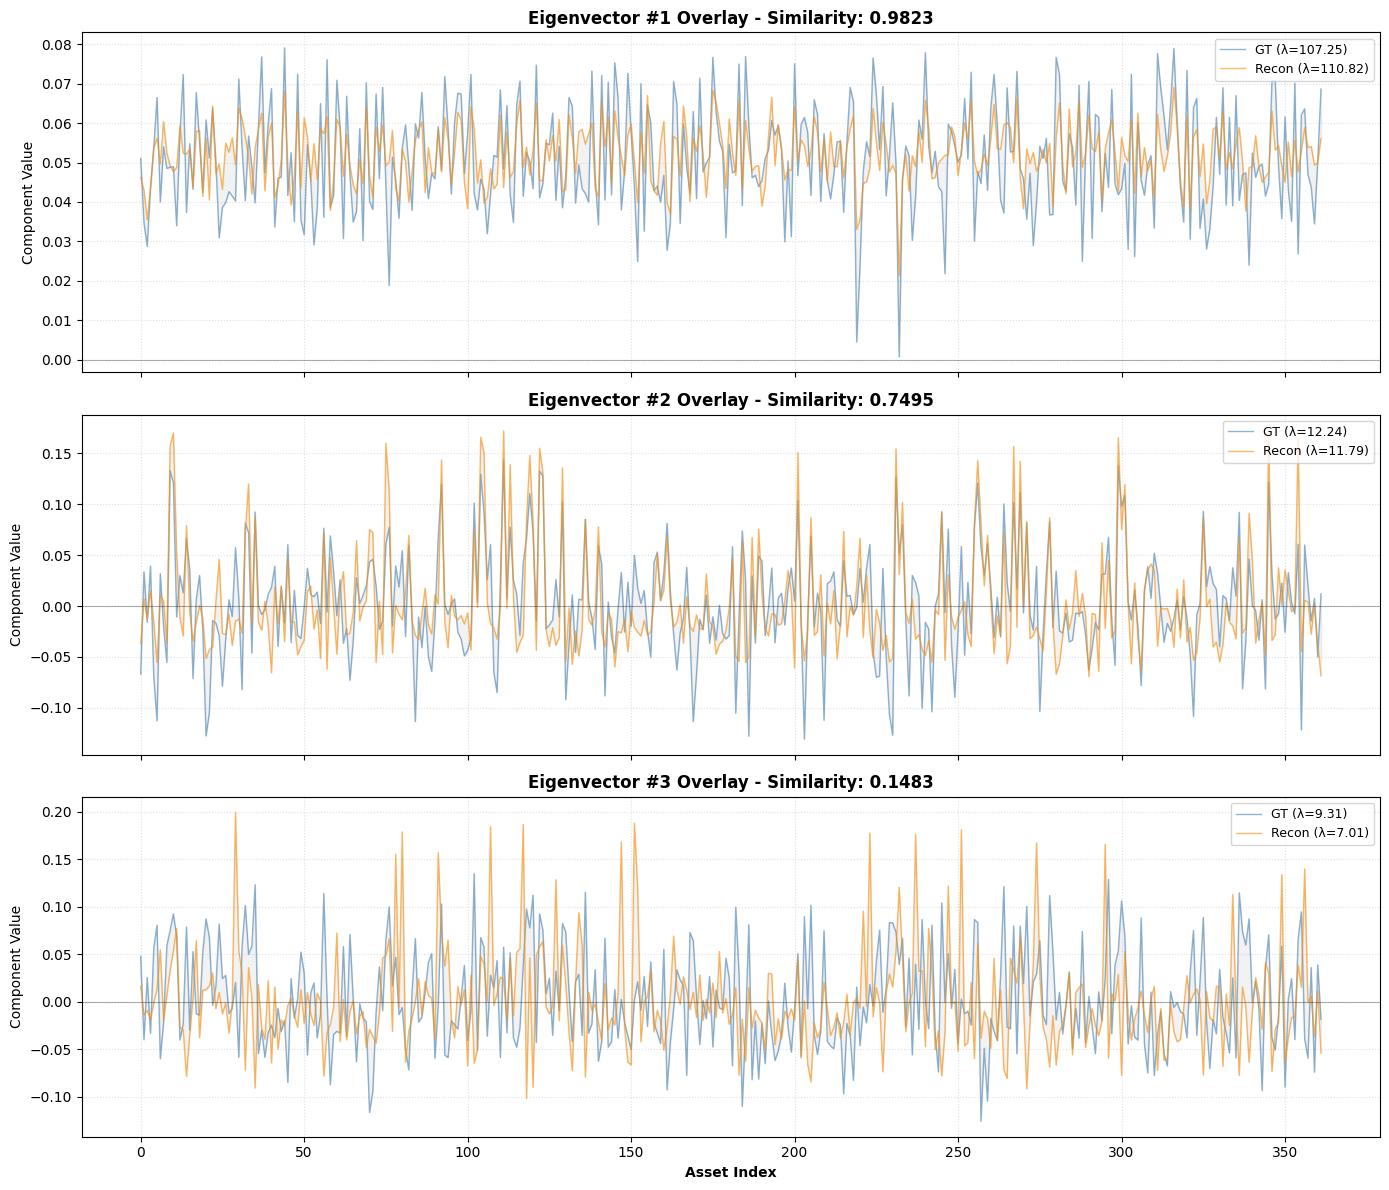

In [94]:
PROPERTY_3_FOLDER = SAMPLE_FOLDER / 'property3'
PROPERTY_3_FOLDER.mkdir(parents=True, exist_ok=True)

def process_eigenvector(vec):
    """Normalizza il segno dell'autovettore per coerenza nel confronto."""
    v = vec.copy()
    if np.sum(v) < 0:
        v = -v
    return v

print(f"\n{'='*60}")
print(f"OVERLAY COMPARISON: TOP 3 EIGENVECTORS (global sample index {SAMPLE_GLOBAL_IDX}, local position {SAMPLE_IDX})")
print(f"{'='*60}")

# Figura con 3 righe, linee sottili e sovrapposte
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
asset_idx = np.arange(num_assets)

for eig_idx in range(3):
    # --- Estrazione e Processamento ---
    vec_gt = process_eigenvector(evecs_gt_np[:, eig_idx])
    vec_recon = process_eigenvector(evecs_recon_np[:, eig_idx])
    val_gt = evals_gt_np[eig_idx]
    val_recon = evals_recon_np[eig_idx]
    
    ax = axes[eig_idx]
    
    # --- Plot Lineare con Trasparenza e Linee Sottili ---
    # GT Line: Blu acciaio, sottile, semi-trasparente
    ax.plot(asset_idx, vec_gt, label=f'GT (λ={val_gt:.2f})', 
            color='steelblue', lw=1, alpha=0.6)
    
    # Recon Line: Arancio scuro, sottile, semi-trasparente
    ax.plot(asset_idx, vec_recon, label=f'Recon (λ={val_recon:.2f})', 
            color='darkorange', lw=1, alpha=0.6)
    
    # Riempimento dell'area di intersezione per migliorare la visibilità
    ax.fill_between(asset_idx, vec_gt, vec_recon, color='gray', alpha=0.1)
    
    # --- Metriche e Titoli ---
    similarity = np.dot(vec_gt, vec_recon) / (np.linalg.norm(vec_gt) * np.linalg.norm(vec_recon))
    
    ax.set_title(f"Eigenvector #{eig_idx+1} Overlay - Similarity: {similarity:.4f}", 
                 fontweight='bold', fontsize=12)
    ax.axhline(0, color='black', lw=0.8, alpha=0.3)
    ax.grid(True, linestyle=':', alpha=0.4)
    ax.legend(loc='upper right', fontsize=9, framealpha=0.8)
    ax.set_ylabel('Component Value')

    # Logica Perron-Frobenius
    if eig_idx == 0:
        pf_gt = np.all(vec_gt >= -1e-5)
        pf_recon = np.all(vec_recon >= -1e-5)
        print(f"Eigenvector #1 (Market Mode):")
        print(f"  GT    -> PF Satisfied: {pf_gt}, Min: {np.min(vec_gt):.6f}, Max: {np.max(vec_gt):.6f}")
        print(f"  Recon -> PF Satisfied: {pf_recon}, Min: {np.min(vec_recon):.6f}, Max: {np.max(vec_recon):.6f}")

axes[-1].set_xlabel('Asset Index', fontweight='bold')

plt.tight_layout()

# Salvataggio
plot_path = PROPERTY_3_FOLDER / 'perron_frobenius.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
print(f"\n✓ Overlay comparison plot saved to: {plot_path}")

plt.show()


# Property 4: Correlations have a hierarchical structure

In [95]:
PROPERTY_4_FOLDER = SAMPLE_FOLDER / 'property4'
PROPERTY_4_FOLDER.mkdir(parents=True, exist_ok=True)

def sanitize_correlation_matrix(corr_matrix):
    corr_matrix = np.clip(corr_matrix, -1.0, 1.0)
    corr_matrix = (corr_matrix + corr_matrix.T) / 2.0
    np.fill_diagonal(corr_matrix, 1.0)
    
    return corr_matrix

def build_distance_matrix(corr_matrix):
    dist_matrix = np.sqrt(np.maximum(0.0, 2.0 * (1.0 - corr_matrix)))
    dist_matrix = (dist_matrix + dist_matrix.T) / 2.0
    np.fill_diagonal(dist_matrix, 0.0)
    
    return dist_matrix

✓ Comparison dendrograms saved to: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\results\data_00_20_w724_s10\reconstruction_analysis\linearAE_005\sample_49\property4\comparison_dendrograms.png


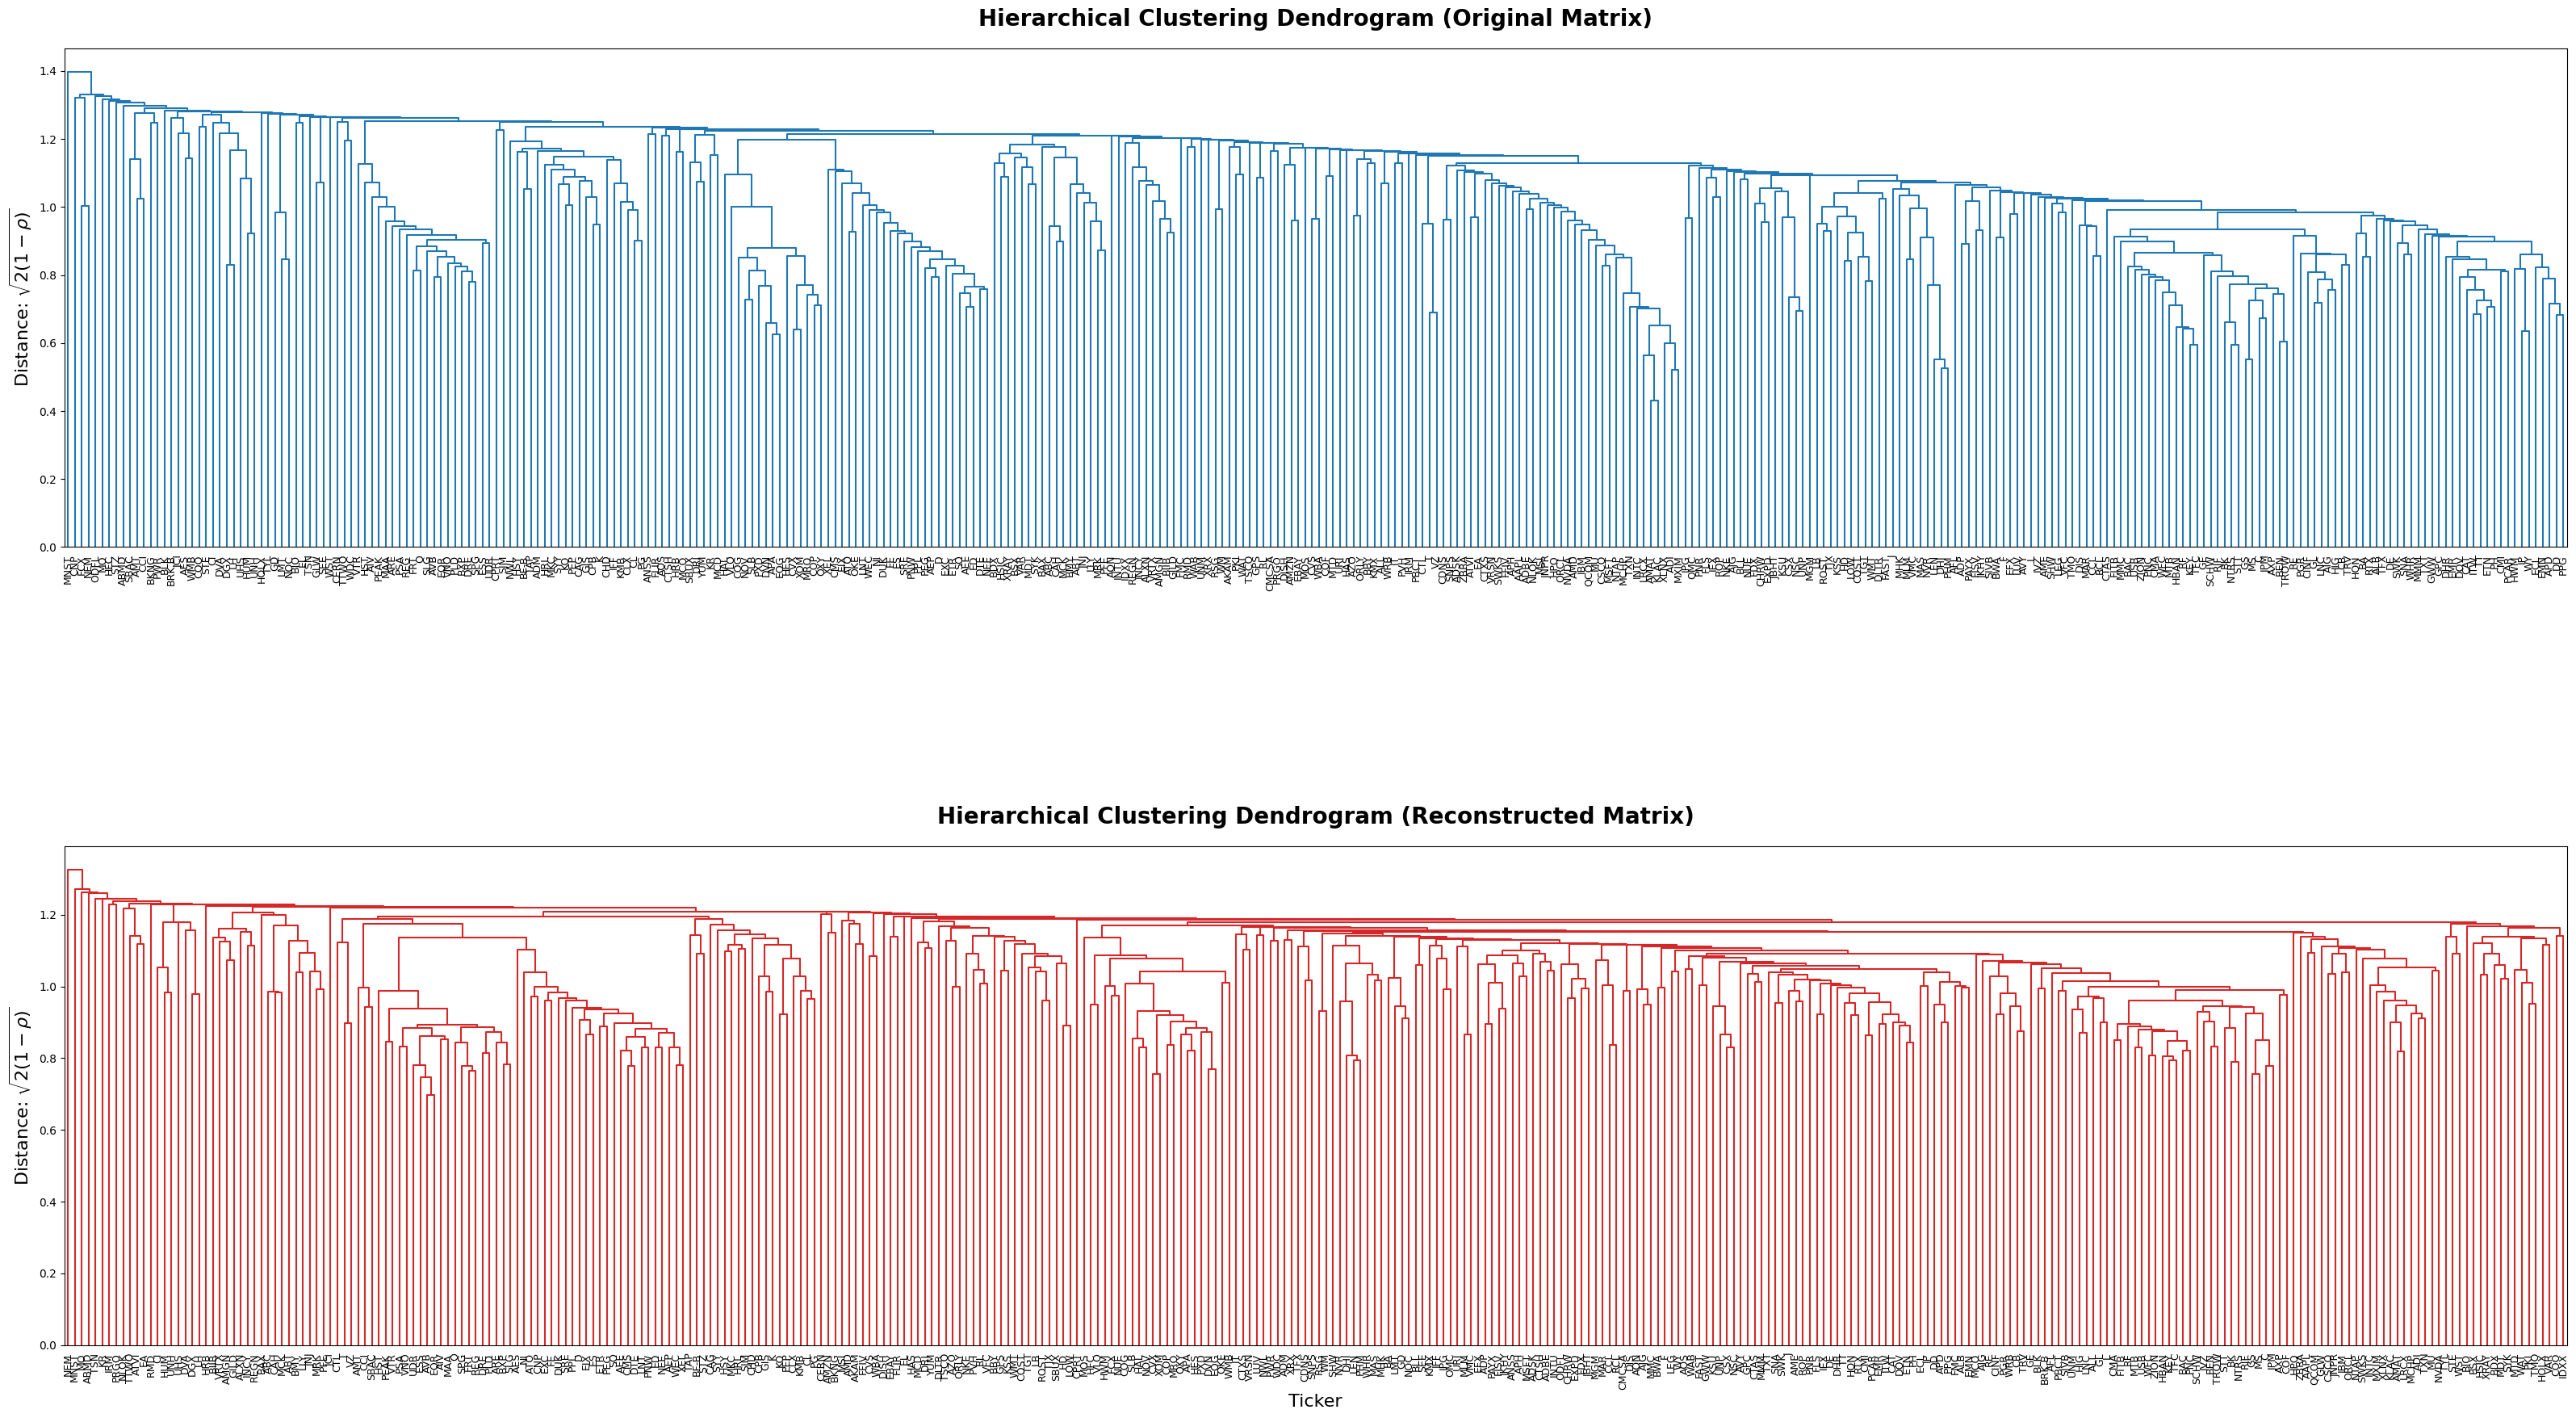

In [96]:
# --- 1. PREPARAZIONE DATI ---

# Calcolo linkage MATRICE ORIGINALE
sanitized_orig_mat = sanitize_correlation_matrix(orig_mat)
dist_matrix_orig = build_distance_matrix(sanitized_orig_mat)
condensed_dist_orig = squareform(dist_matrix_orig, checks=False)
Z_orig = linkage(condensed_dist_orig, method='average')

# Calcolo linkage MATRICE RICOSTRUITA
sanitized_recon_mat = sanitize_correlation_matrix(recon_mat)
dist_matrix_recon = build_distance_matrix(sanitized_recon_mat)
condensed_dist_recon = squareform(dist_matrix_recon, checks=False)
Z_recon = linkage(condensed_dist_recon, method='average')

labels = meta['tickers']

# --- 2. GENERAZIONE DENDROGRAMMI (Sopra vs Sotto) ---

# Creiamo una figura con due sottografici (2 righe, 1 colonna)
fig, (ax_top, ax_bottom) = plt.subplots(2, 1, figsize=(40, 22))

# Configurazione colori e stile
color_orig = 'tab:blue'
color_recon = 'tab:red'

# --- Dendrogramma Matrice Originale (Sopra) ---
dendrogram(
    Z_orig,
    labels=labels,
    leaf_rotation=90,
    leaf_font_size=9,
    ax=ax_top,
    color_threshold=0,
    above_threshold_color=color_orig,
    link_color_func=lambda _: color_orig,
)
ax_top.set_title('Hierarchical Clustering Dendrogram (Original Matrix)', fontsize=20, fontweight='bold', pad=20)
ax_top.set_ylabel(r'Distance: $\sqrt{2(1-\rho)}$', fontsize=16)

# --- Dendrogramma Matrice Ricostruita (Sotto) ---
dendrogram(
    Z_recon,
    labels=labels,
    leaf_rotation=90,
    leaf_font_size=9,
    ax=ax_bottom,
    color_threshold=0,
    above_threshold_color=color_recon,
    link_color_func=lambda _: color_recon,
)
ax_bottom.set_title('Hierarchical Clustering Dendrogram (Reconstructed Matrix)', fontsize=20, fontweight='bold', pad=20)
ax_bottom.set_xlabel('Ticker', fontsize=16)
ax_bottom.set_ylabel(r'Distance: $\sqrt{2(1-\rho)}$', fontsize=16)

# --- Rifiniture Layout ---

# hspace regola la distanza verticale tra i due grafici
# bottom riserva spazio per le etichette dei ticker in basso
plt.subplots_adjust(hspace=0.6, bottom=0.15)

# Salvataggio
dendrogram_path = PROPERTY_4_FOLDER / 'comparison_dendrograms.png'
plt.savefig(dendrogram_path, dpi=300, bbox_inches='tight')

print(f"✓ Comparison dendrograms saved to: {dendrogram_path}")
plt.show()

# Property 5: The Minimum Spanning Tree (MST) obtained from a correlation matrix satisfies the scale-free property

✓ Plot salvato: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\results\data_00_20_w724_s10\reconstruction_analysis\linearAE_005\sample_49\property5\mst_degree_distribution.png


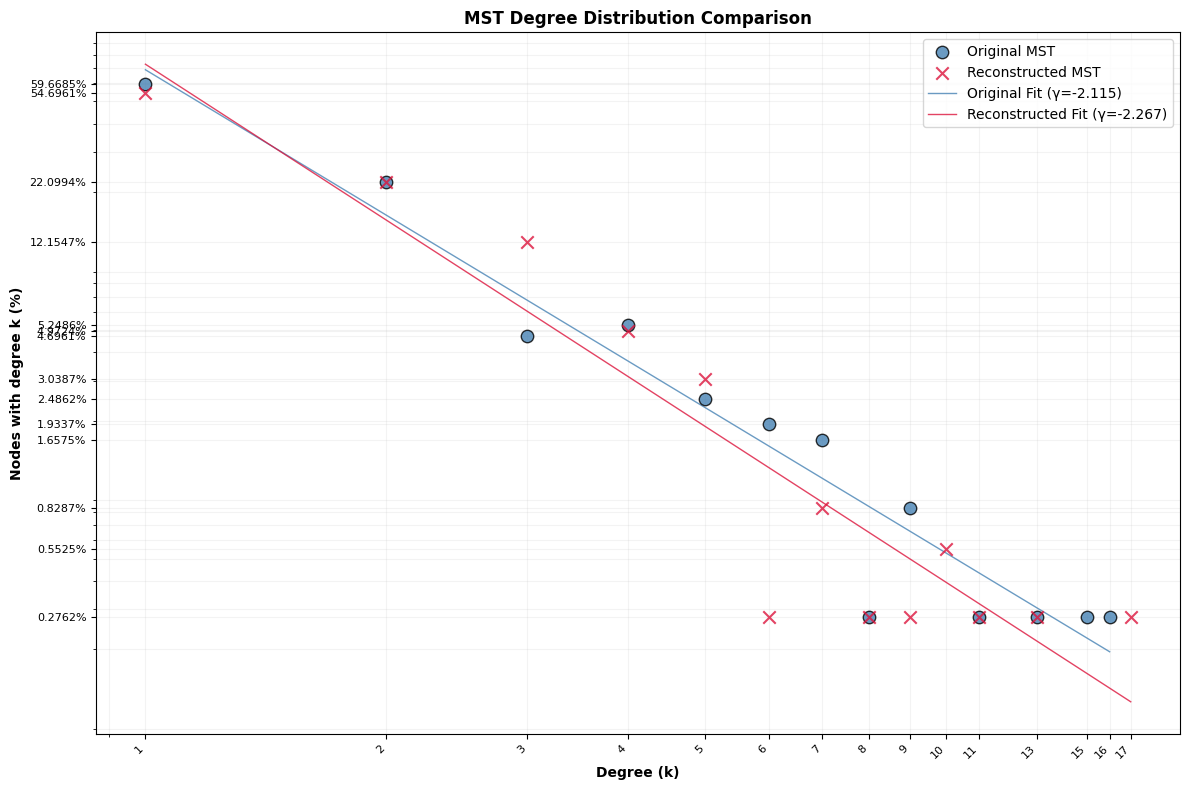

In [102]:
# Presumendo che adj_gt e adj_recon siano le matrici di adiacenza degli MST
# (Matrici binarie NxN dove 1 indica un arco nell'MST)

def compute_degrees_from_mst(adj_matrix):
    """Calcola il grado di ogni nodo da una matrice di adiacenza."""
    # Assicuriamoci che sia un array numpy
    adj = np.array(adj_matrix)
    # Il grado è semplicemente la somma delle righe (o colonne)
    degrees = np.sum(adj, axis=1).astype(int)
    return degrees

def get_mst_adjacency(matrix):
    """
    Data una matrice di pesi (distanze o 1-correlazione), 
    restituisce la matrice di adiacenza binaria dell'MST.
    """
    # 1. Calcola l'MST (restituisce una matrice sparsa con i pesi originali)
    mst_sparse = minimum_spanning_tree(matrix)
    
    # 2. Converti in matrice densa e trasforma in binaria (1 se c'è un arco, 0 altrimenti)
    mst_binary = (mst_sparse.toarray() > 0).astype(int)
    
    # 3. L'MST di SciPy è diretto (triangolare superiore). 
    # Per il calcolo dei gradi, rendiamola simmetrica.
    mst_full = mst_binary + mst_binary.T
    
    return mst_full

# --- ESEMPIO DI UTILIZZO ---

# Supponendo che 'dist_gt' e 'dist_recon' siano le tue matrici di distanza NxN
# Se hai matrici di correlazione 'corr', usa (1 - np.abs(corr)) come input
adj_gt = get_mst_adjacency(dist_matrix_orig)
adj_recon = get_mst_adjacency(dist_matrix_recon)

# 1. Calcolo dei gradi per GT e RECON
deg_orig = compute_degrees_from_mst(adj_gt) 
deg_recon = compute_degrees_from_mst(adj_recon)

# 2. Definizione cartella e path di output
PROPERTY_5_FOLDER = SAMPLE_FOLDER / 'property5'
PROPERTY_5_FOLDER.mkdir(parents=True, exist_ok=True)
out_png = PROPERTY_5_FOLDER / 'mst_degree_distribution.png'

# 3. Chiamata alla funzione (usando il tuo codice con una piccola ottimizzazione per i ticks)
def plot_degree_distribution_refined(deg_orig, deg_recon, out_png):
    max_degree = int(max(deg_orig.max(), deg_recon.max()))
    counts_orig = np.bincount(deg_orig, minlength=max_degree + 1)
    counts_recon = np.bincount(deg_recon, minlength=max_degree + 1)
    
    freq_orig = counts_orig / counts_orig.sum()
    freq_recon = counts_recon / counts_recon.sum()

    degrees_arr = np.arange(max_degree + 1)
    
    mask_orig = freq_orig > 0
    mask_recon = freq_recon > 0
    
    x_orig = degrees_arr[mask_orig & (degrees_arr > 0)]
    y_orig = freq_orig[mask_orig & (degrees_arr > 0)] * 100.0
    
    x_recon = degrees_arr[mask_recon & (degrees_arr > 0)]
    y_recon = freq_recon[mask_recon & (degrees_arr > 0)] * 100.0

    fig, ax = plt.subplots(figsize=(12, 8))
    
    # --- MODIFICA MARKER ---
    # Originale: pallini blu ('o')
    ax.scatter(x_orig, y_orig, s=80, alpha=0.8, color='steelblue', marker='o', 
               edgecolor='black', label='Original MST', zorder=3)
    
    # Ricostruito: x rosse ('x')
    ax.scatter(x_recon, y_recon, s=80, alpha=0.8, color='crimson', marker='x', 
               label='Reconstructed MST', zorder=3)

    # Gestione Assi (Log-Log con valori esatti)
    all_x = np.unique(np.concatenate([x_orig, x_recon]))
    if len(all_x) > 0:
        ax.set_xscale('log')
        ax.set_xticks(all_x)
        ax.set_xticklabels([f'{int(k)}' for k in all_x], rotation=45, ha='right', fontsize=8)

    all_y = np.unique(np.concatenate([y_orig, y_recon]))
    if len(all_y) > 0:
        ax.set_yscale('log')
        ax.set_yticks(all_y)
        ax.set_yticklabels([f'{val:.4f}%' for val in all_y], fontsize=8)

    # --- MODIFICA LINEE (CONTINUE) ---
    def fit_and_plot(x, y, color, label):
        if len(x) >= 2:
            slope, intercept = np.polyfit(np.log10(x), np.log10(y), 1)
            y_fit = 10 ** (intercept + slope * np.log10(x))
            
            ax.plot(x, y_fit, color=color, lw=1.0, ls='-', alpha=0.8, 
                    label=f'{label} Fit (γ={slope:.3f})')

    fit_and_plot(x_orig, y_orig, 'steelblue', 'Original')
    fit_and_plot(x_recon, y_recon, 'crimson', 'Reconstructed')

    # Estetica finale
    ax.set_xlabel('Degree (k)', fontweight='bold')
    ax.set_ylabel('Nodes with degree k (%)', fontweight='bold')
    ax.set_title('MST Degree Distribution Comparison', fontweight='bold')
    ax.grid(True, which="both", ls="-", alpha=0.15)
    ax.legend(frameon=True, loc='best')

    plt.tight_layout()
    plt.savefig(out_png, dpi=160, bbox_inches='tight')
    print(f'✓ Plot salvato: {out_png}')
    plt.show()

# Esecuzione
plot_degree_distribution_refined(deg_orig, deg_recon, out_png)
